# **SIMULATION**

### 1. Theory

For our PINN, we will consider solving Newton's law of cooling,

$$
\frac{dT}{dt} = \alpha (T-T_s)
$$

where $dT/dt$ is the rate of cooling, $\alpha$ is the cooling rate, $T$ is the temperature of the system and $T_s$ is that of the surroundings. Given the initial condition $T(t=0)=T_0$ where $T_0$ is the system's initial temperature, the analytic solution to the ODE can be written as,

$$
T(t) = T_s + (T_0 - T_s)e^{-\alpha t}
$$

Inspecting the form of the solution, we can see that the system has a temperature of $T_0$ at $t=0$. The temperature of the system then exponentially decays to that of the surroundings $T_s$. This decay is characterised by the material constant $\alpha$ (rate of cooling) and the temperature gradient $\Delta T = T_0 - T_s$ between the system and its surroundings. Let us plot $T(t)$ for  

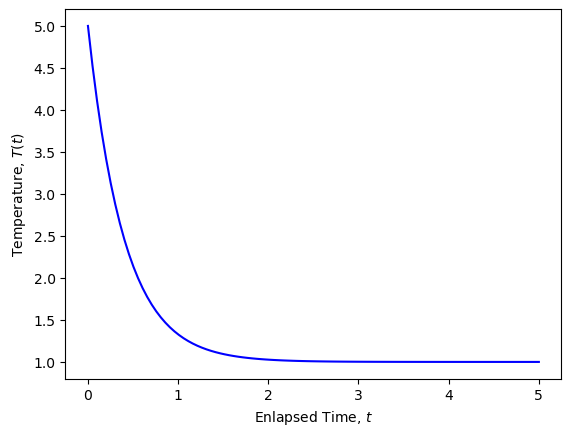

In [16]:
# Importing,
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def solution(t, alpha, T_0, T_s):
    return T_s + (T_0 - T_s)*np.exp(-alpha*t)

# Parameters
alpha = 2.5
T_0 = 5
T_s = 1

# Graphing,
t = np.linspace(start=0, stop=5, num=100)
sol = solution(t, alpha, T_0, T_s)
plt.plot(t, sol, color="blue")
plt.xlabel("Enlapsed Time, $t$")
plt.ylabel("Temperature, $T(t)$")
plt.show()

### 2. Dataset

Now we create a dataset which consists of randomly sampled points $(t_i, T_i)$. We will restrict ourselves to only samplings points where $0 \leq t \leq 0.75$ for the training dataset. However, we use the entire domain for the testing dataset. Note that we use uniform sampling and sample `N=200` points for training and`N=75` for testing.

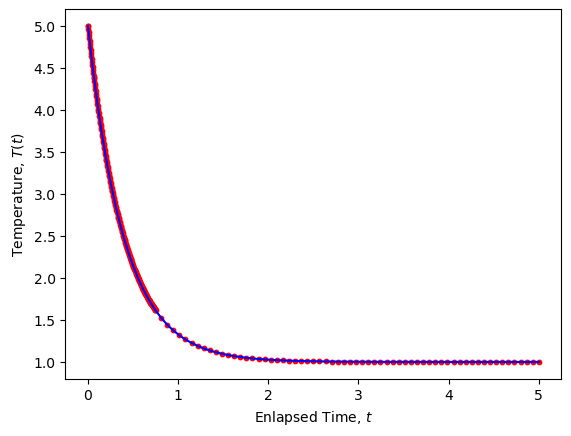

In [43]:
# Sampling points,
t_train = np.linspace(start = 0, stop = 0.75, num=200)
t_test = np.linspace(start = 0, stop = 5, num=75)
T_train = solution(t_train, alpha, T_0, T_s)
T_test = solution(t_test, alpha, T_0, T_s)

# Plotting,
plt.plot(t, sol, color="blue")
plt.scatter(t_train, T_train, color="red", s=10)
plt.scatter(t_test, T_test, color="red", s=10)
plt.xlabel("Enlapsed Time, $t$")
plt.ylabel("Temperature, $T(t)$")
plt.show()

Saving the dataset,

In [41]:
"""# Random shuffling,
SEED = 0
rng = np.random.default_rng(SEED)
perm_test = rng.permutation(len(t_test))
perm_train = rng.permutation(len(t_train))
t_train = t_train[perm_train]
T_train = T_train[perm_train]
t_test = t_test[perm_test]
T_test = T_test[perm_test]"""

# Saving dataset,
np.save("train.npy", arr=(t_train, T_train))
np.save("test.npy", arr=(t_test, T_test))